In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.metrics import classification_report, confusion_matrix


In [2]:

df = pd.read_csv("syndrome_dataset.csv")

# Drop ID
df = df.drop(columns=["patient_id"])

# Features / target
X = df.drop(columns=["syndrome"])
y = df["syndrome"]

numeric_features = ["temperature_c", "fever_days"]
binary_features = ["stool_diarrhea", "mental_wellness_altered", "cough"]


In [3]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [10]:

tree_clf = DecisionTreeClassifier(
    criterion="gini",
    max_depth=4,
    min_samples_leaf=10,
    class_weight="balanced",
    random_state=42
)
tree_clf.fit(X_train, y_train)
y_pred = tree_clf.predict(X_test)


In [12]:

print("Classification Report: for Decision Tree\n")
print(classification_report(y_test, y_pred))
from sklearn.tree import plot_tree



Classification Report: for Decision Tree

              precision    recall  f1-score   support

         AES       0.94      1.00      0.97        45
         ARI       0.94      0.87      0.90        67
        AUFI       0.98      1.00      0.99        58
       OTHER       0.81      0.83      0.82        30

    accuracy                           0.93       200
   macro avg       0.92      0.92      0.92       200
weighted avg       0.93      0.93      0.93       200



[Text(0.5595238095238095, 0.9, 'mental_wellness_altered <= 0.5\ngini = 0.75\nsamples = 800\nvalue = [200.0, 200.0, 200.0, 200.0]\nclass = ARI'),
 Text(0.2619047619047619, 0.7, 'cough <= 0.5\ngini = 0.666\nsamples = 585\nvalue = [0.0, 180.524, 200.0, 185.366]\nclass = AUFI'),
 Text(0.4107142857142857, 0.8, 'True  '),
 Text(0.09523809523809523, 0.5, 'temperature_c <= 37.95\ngini = 0.411\nsamples = 280\nvalue = [0.0, 0.0, 200.0, 81.301]\nclass = AUFI'),
 Text(0.047619047619047616, 0.3, 'gini = 0.0\nsamples = 30\nvalue = [0.0, 0.0, 0.0, 48.78]\nclass = OTHER'),
 Text(0.14285714285714285, 0.3, 'temperature_c <= 38.65\ngini = 0.241\nsamples = 250\nvalue = [0.0, 0.0, 200.0, 32.52]\nclass = AUFI'),
 Text(0.09523809523809523, 0.1, 'gini = 0.456\nsamples = 71\nvalue = [0.0, 0.0, 47.826, 26.016]\nclass = AUFI'),
 Text(0.19047619047619047, 0.1, 'gini = 0.079\nsamples = 179\nvalue = [0.0, 0.0, 152.174, 6.504]\nclass = AUFI'),
 Text(0.42857142857142855, 0.5, 'temperature_c <= 38.05\ngini = 0.464\nsa

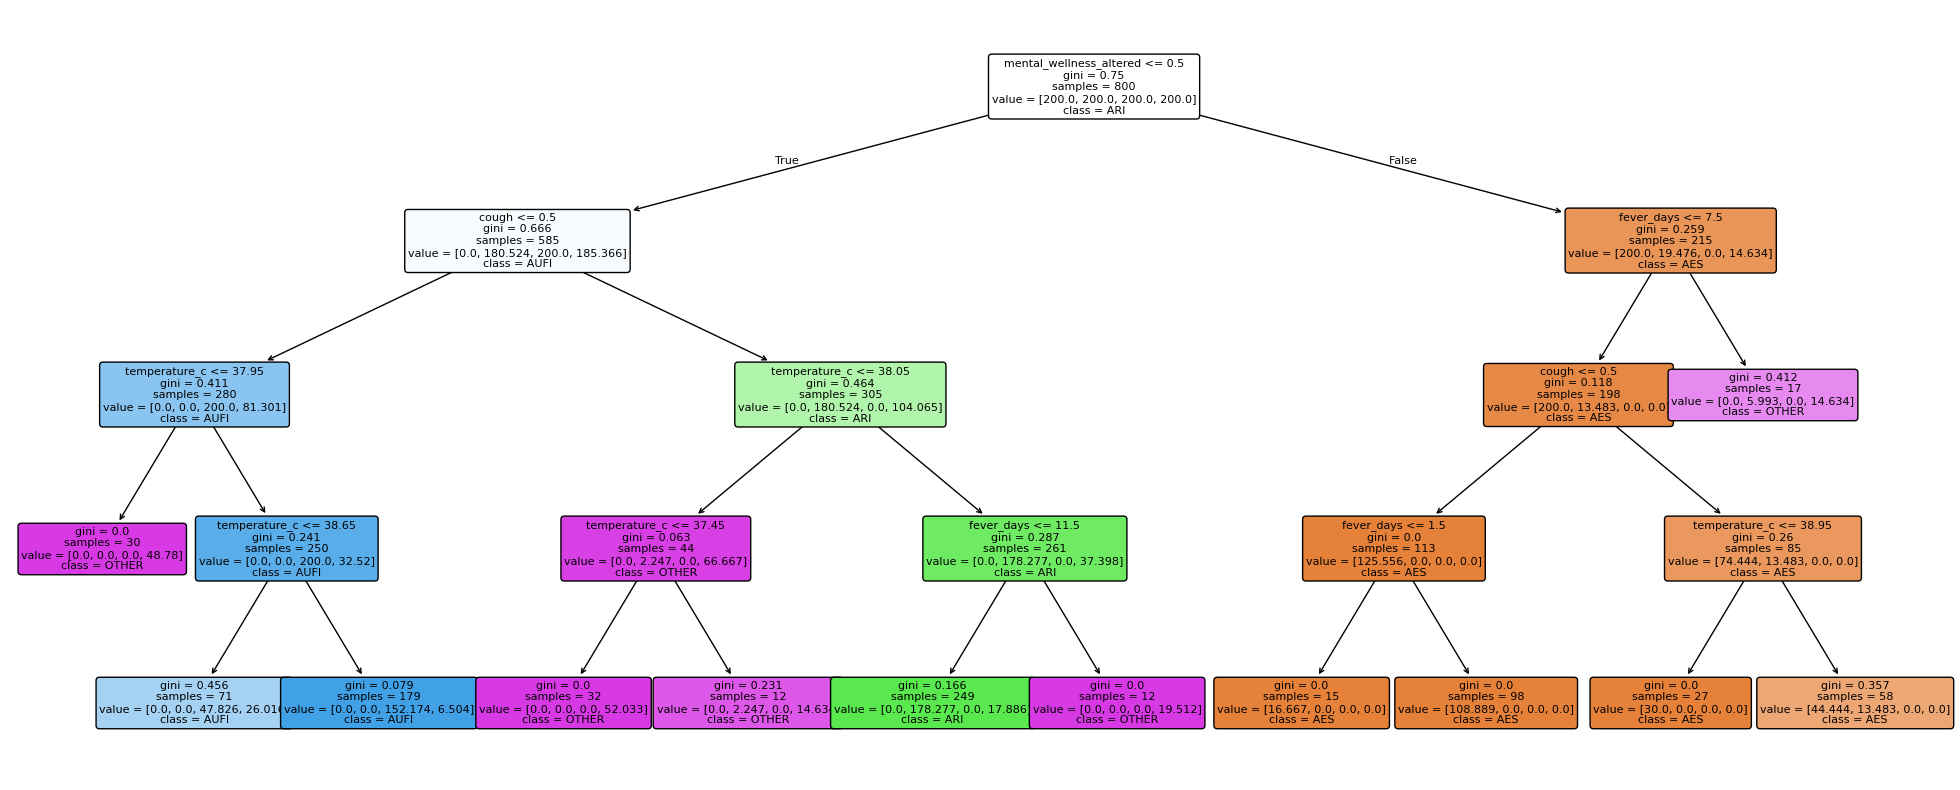

In [6]:

plt.figure(figsize=(25, 10))
plot_tree(
    tree_clf,
    feature_names=X.columns,
    class_names=tree_clf.classes_,  # ['AES', 'ARI', 'AUFI', 'OTHER']
    filled=True,
    rounded=True,
    fontsize=8
)

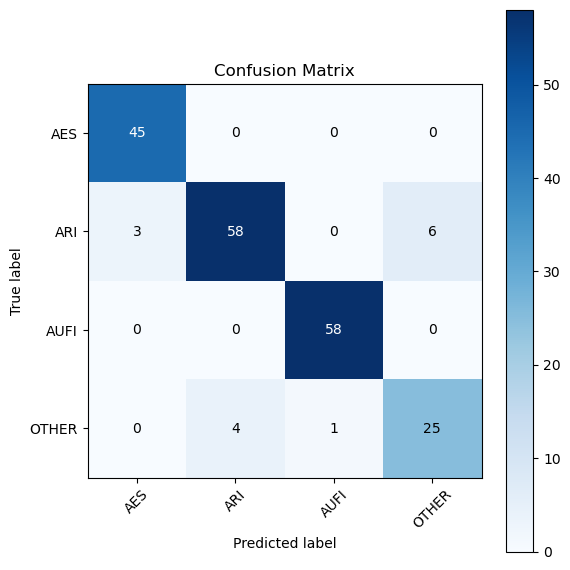

In [8]:
cm = confusion_matrix(y_test, y_pred)
labels_cm = tree_clf.classes_

plt.figure(figsize=(6,6))
plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(labels_cm))
plt.xticks(tick_marks, labels_cm, rotation=45)
plt.yticks(tick_marks, labels_cm)

plt.xlabel("Predicted label")
plt.ylabel("True label")

# Add values inside the matrix
thresh = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 ha="center", va="center",
                 color="white" if cm[i, j] > thresh else "black")

plt.tight_layout()
plt.show()



In [9]:
feature_names = X.columns.tolist()
rules = export_text(tree_clf, feature_names=feature_names)
print("\nDecision Tree Rules:\n")
print(rules)


Decision Tree Rules:

|--- mental_wellness_altered <= 0.50
|   |--- cough <= 0.50
|   |   |--- temperature_c <= 37.95
|   |   |   |--- class: OTHER
|   |   |--- temperature_c >  37.95
|   |   |   |--- temperature_c <= 38.65
|   |   |   |   |--- class: AUFI
|   |   |   |--- temperature_c >  38.65
|   |   |   |   |--- class: AUFI
|   |--- cough >  0.50
|   |   |--- temperature_c <= 38.05
|   |   |   |--- temperature_c <= 37.45
|   |   |   |   |--- class: OTHER
|   |   |   |--- temperature_c >  37.45
|   |   |   |   |--- class: OTHER
|   |   |--- temperature_c >  38.05
|   |   |   |--- fever_days <= 11.50
|   |   |   |   |--- class: ARI
|   |   |   |--- fever_days >  11.50
|   |   |   |   |--- class: OTHER
|--- mental_wellness_altered >  0.50
|   |--- fever_days <= 7.50
|   |   |--- cough <= 0.50
|   |   |   |--- fever_days <= 1.50
|   |   |   |   |--- class: AES
|   |   |   |--- fever_days >  1.50
|   |   |   |   |--- class: AES
|   |   |--- cough >  0.50
|   |   |   |--- temperature_c 